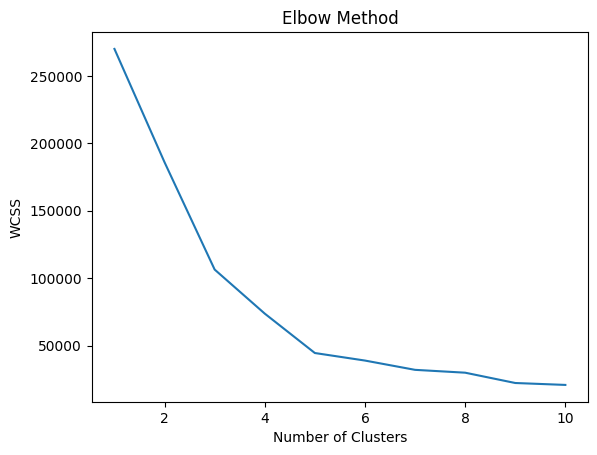

Clustered data saved as clustered_customers.csv


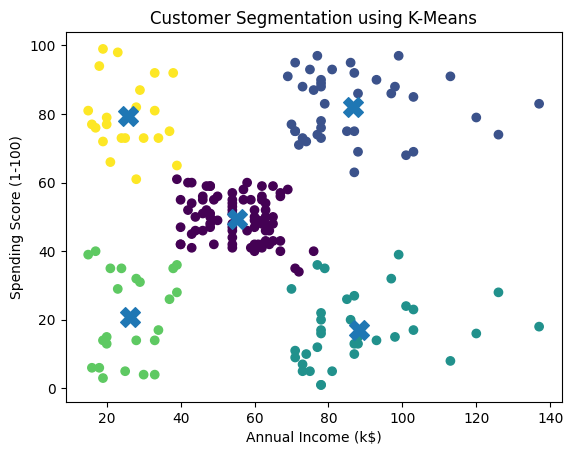

Graphs saved as elbow_graph.png and cluster_graph.png


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ----------------------------
# Load Dataset
# ----------------------------
data = pd.read_csv("Mall_Customers.csv")

# Select features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# ----------------------------
# Elbow Method
# ----------------------------
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure()
plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

# Save graph
plt.savefig("elbow_graph.png")

plt.show()

# ----------------------------
# Apply KMeans
# ----------------------------
kmeans = KMeans(n_clusters=5, random_state=0)

clusters = kmeans.fit_predict(X)

# Add cluster column
data['Cluster'] = clusters

# ----------------------------
# Save Output Dataset
# ----------------------------
data.to_csv("clustered_customers.csv", index=False)

print("Clustered data saved as clustered_customers.csv")

# ----------------------------
# Plot Clusters
# ----------------------------
plt.figure()

plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c=clusters)

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            marker='X',
            s=200)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

# Save cluster graph
plt.savefig("cluster_graph.png")

plt.show()

print("Graphs saved as elbow_graph.png and cluster_graph.png")